In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path='/content/HR Analytics Data.csv'

In [3]:
df=pd.read_csv(file_path)

In [4]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
248,37,No,Travel_Rarely,1017,Research & Development,1,2,Medical,1,340,...,1,80,1,17,2,2,3,1,0,2
429,46,No,Travel_Rarely,1009,Research & Development,2,3,Life Sciences,1,575,...,3,80,0,26,2,1,3,2,0,1
859,29,No,Travel_Rarely,942,Research & Development,15,1,Life Sciences,1,1202,...,1,80,1,6,2,2,5,4,1,3
428,47,No,Travel_Rarely,983,Research & Development,2,2,Medical,1,574,...,3,80,3,20,2,3,5,0,0,4
266,31,No,Travel_Rarely,1463,Research & Development,23,3,Medical,1,367,...,2,80,1,10,2,3,9,0,7,8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(f"Overall Attrition Rate: {attrition_rate['Yes']:.2f}%")

Overall Attrition Rate: 16.12%


In [8]:
department_attrition = df.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
department_attrition['AttritionRate'] = (department_attrition['Yes'] / (department_attrition['No'] + department_attrition['Yes'])) * 100
print(department_attrition[['Yes', 'No', 'AttritionRate']])

Attrition               Yes   No  AttritionRate
Department                                     
Human Resources          12   51      19.047619
Research & Development  133  828      13.839750
Sales                    92  354      20.627803


In [9]:
JobRole_attrition = df.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)
JobRole_attrition['AttritionRate'] = (JobRole_attrition['Yes'] / (JobRole_attrition['No'] + JobRole_attrition['Yes'])) * 100
print(JobRole_attrition[['Yes', 'No', 'AttritionRate']])

Attrition                  Yes   No  AttritionRate
JobRole                                           
Healthcare Representative    9  122       6.870229
Human Resources             12   40      23.076923
Laboratory Technician       62  197      23.938224
Manager                      5   97       4.901961
Manufacturing Director      10  135       6.896552
Research Director            2   78       2.500000
Research Scientist          47  245      16.095890
Sales Executive             57  269      17.484663
Sales Representative        33   50      39.759036


In [10]:
Gender_attrition = df.groupby(['Gender', 'Attrition']).size().unstack(fill_value=0)
Gender_attrition['AttritionRate'] = (Gender_attrition['Yes'] / (Gender_attrition['No'] + Gender_attrition['Yes'])) * 100
print(Gender_attrition[['Yes', 'No', 'AttritionRate']])

Attrition  Yes   No  AttritionRate
Gender                            
Female      87  501      14.795918
Male       150  732      17.006803


/tmp/ipykernel_3691/3278696098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=department_attrition.index, y=department_attrition['AttritionRate'], palette='viridis')


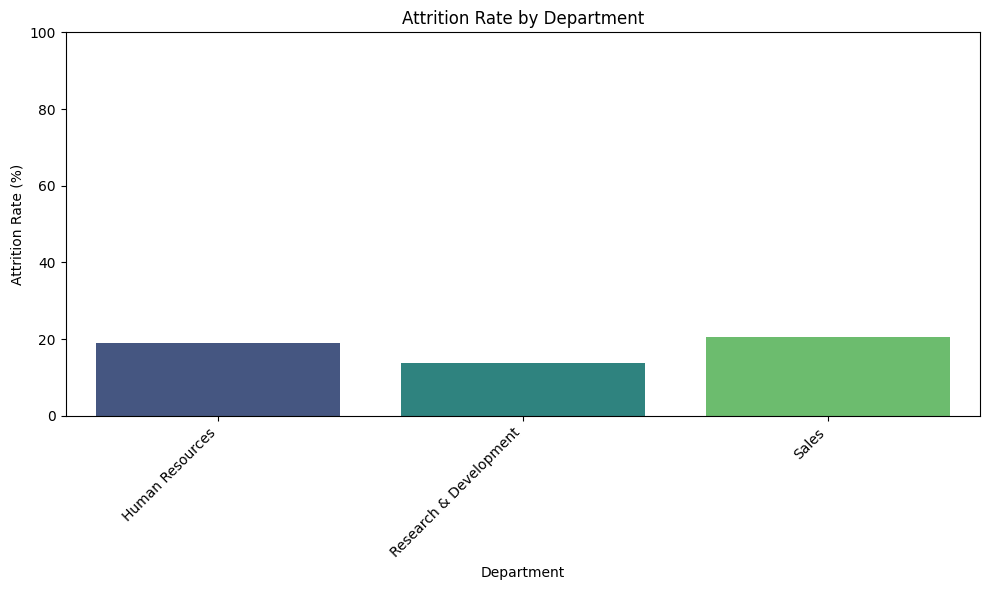

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x=department_attrition.index, y=department_attrition['AttritionRate'], palette='viridis')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100 for percentage
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3691/2642944730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Gender_attrition.index, y=Gender_attrition['AttritionRate'], palette='coolwarm')


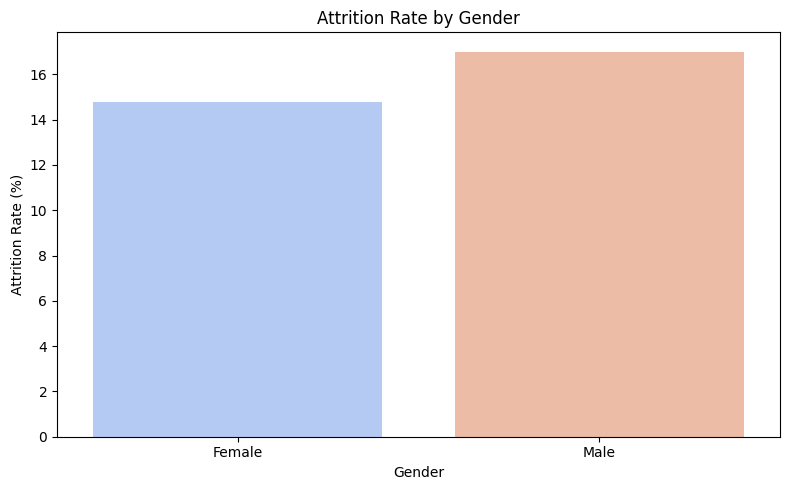

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=Gender_attrition.index, y=Gender_attrition['AttritionRate'], palette='coolwarm')
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (%)')
#plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Attrition        Yes   No  AttritionRate
JobSatisfaction                         
1                 66  223      22.837370
2                 46  234      16.428571
3                 73  369      16.515837
4                 52  407      11.328976


/tmp/ipykernel_3691/4211797266.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=JobSatisfaction_attrition.index, y=JobSatisfaction_attrition['AttritionRate'], palette='viridis')


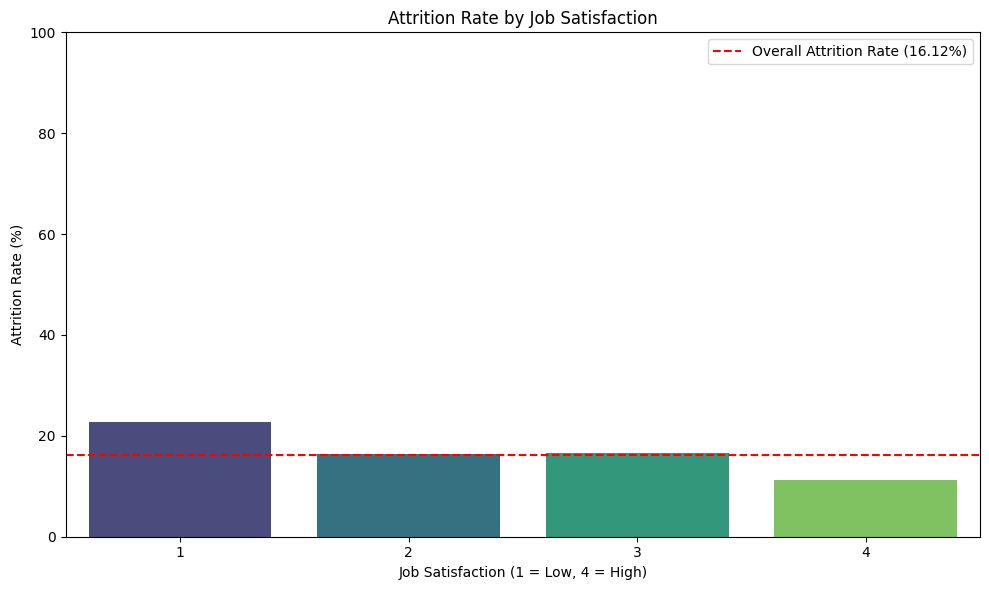

In [15]:
JobSatisfaction_attrition = df.groupby(['JobSatisfaction', 'Attrition']).size().unstack(fill_value=0)
JobSatisfaction_attrition['AttritionRate'] = (JobSatisfaction_attrition['Yes'] / (JobSatisfaction_attrition['No'] + JobSatisfaction_attrition['Yes'])) * 100
print(JobSatisfaction_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=JobSatisfaction_attrition.index, y=JobSatisfaction_attrition['AttritionRate'], palette='viridis')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction (1 = Low, 4 = High)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100 for percentage
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
WorkLifeBalance_attrition = df.groupby(['WorkLifeBalance', 'Attrition']).size().unstack(fill_value=0)
WorkLifeBalance_attrition['AttritionRate'] = (WorkLifeBalance_attrition['Yes'] / (WorkLifeBalance_attrition['No'] + WorkLifeBalance_attrition['Yes'])) * 100
print(WorkLifeBalance_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=WorkLifeBalance_attrition.index, y=WorkLifeBalance_attrition['AttritionRate'], palette='magma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance (1 = Bad, 4 = Excellent)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition        Yes   No  AttritionRate
WorkLifeBalance                         
1                 25   55      31.250000
2                 58  286      16.860465
3                127  766      14.221725
4                 27  126      17.647059


/tmp/ipykernel_3691/572026148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=WorkLifeBalance_attrition.index, y=WorkLifeBalance_attrition['AttritionRate'], palette='magma')


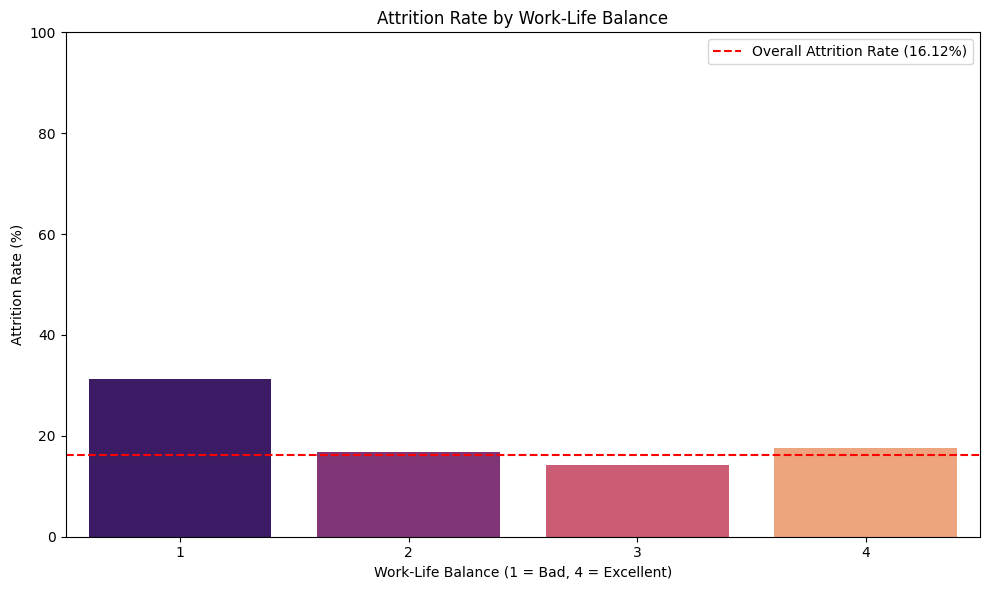

In [16]:
WorkLifeBalance_attrition = df.groupby(['WorkLifeBalance', 'Attrition']).size().unstack(fill_value=0)
WorkLifeBalance_attrition['AttritionRate'] = (WorkLifeBalance_attrition['Yes'] / (WorkLifeBalance_attrition['No'] + WorkLifeBalance_attrition['Yes'])) * 100
print(WorkLifeBalance_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=WorkLifeBalance_attrition.index, y=WorkLifeBalance_attrition['AttritionRate'], palette='magma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance (1 = Bad, 4 = Excellent)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition                Yes   No  AttritionRate
YearsSinceLastPromotion                         
0                        110  471      18.932874
1                         49  308      13.725490
2                         27  132      16.981132
3                          9   43      17.307692
4                          5   56       8.196721
5                          2   43       4.444444
6                          6   26      18.750000
7                         16   60      21.052632
8                          0   18       0.000000
9                          4   13      23.529412
10                         1    5      16.666667
11                         2   22       8.333333
12                         0   10       0.000000
13                         2    8      20.000000
14                         1    8      11.111111
15                         3   10      23.076923


/tmp/ipykernel_3691/2389129441.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=YearsSinceLastPromotion_attrition.index, y=YearsSinceLastPromotion_attrition['AttritionRate'], palette='plasma')


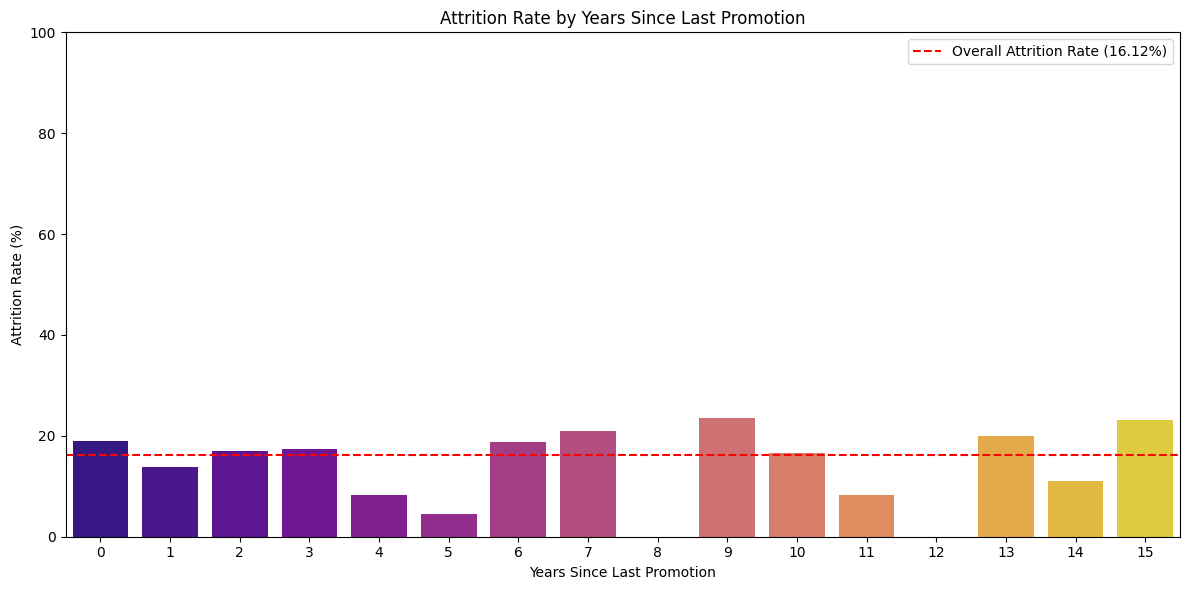

In [21]:
YearsSinceLastPromotion_attrition = df.groupby(['YearsSinceLastPromotion', 'Attrition']).size().unstack(fill_value=0)
YearsSinceLastPromotion_attrition['AttritionRate'] = (YearsSinceLastPromotion_attrition['Yes'] / (YearsSinceLastPromotion_attrition['No'] + YearsSinceLastPromotion_attrition['Yes'])) * 100
print(YearsSinceLastPromotion_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(12, 6))
sns.barplot(x=YearsSinceLastPromotion_attrition.index, y=YearsSinceLastPromotion_attrition['AttritionRate'], palette='plasma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of YearsSinceLastPromotion on the attrition rate

From above plot it is clear that YearsSinceLastPromotion above 7 years have very less input data points which may mislead to the attrition rate  Analysis so upto 7 YearsSinceLastPromotion  should me considered for Analysis

Attrition                Yes   No  AttritionRate
YearsSinceLastPromotion                         
0                        110  471      18.932874
1                         49  308      13.725490
2                         27  132      16.981132
3                          9   43      17.307692
4                          5   56       8.196721
5                          2   43       4.444444
6                          6   26      18.750000
7                         16   60      21.052632
8                          0   18       0.000000
9                          4   13      23.529412
10                         1    5      16.666667
11                         2   22       8.333333
12                         0   10       0.000000
13                         2    8      20.000000
14                         1    8      11.111111
15                         3   10      23.076923


/tmp/ipykernel_3691/2261336711.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_attrition.index, y=filtered_attrition['AttritionRate'], palette='plasma')


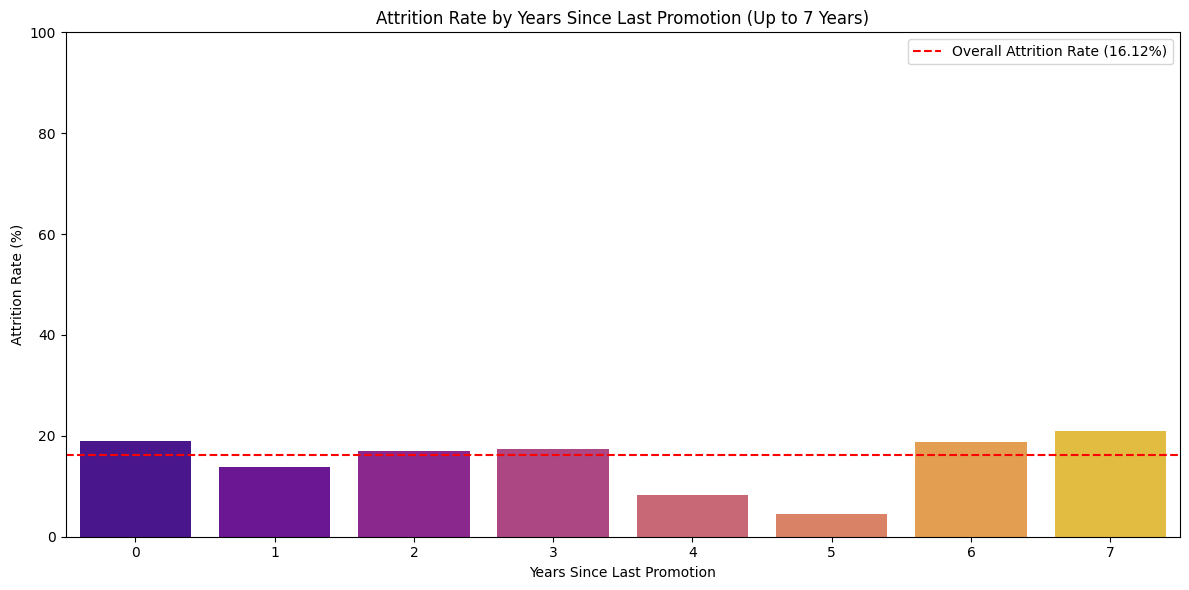

In [22]:
YearsSinceLastPromotion_attrition = df.groupby(['YearsSinceLastPromotion', 'Attrition']).size().unstack(fill_value=0)
YearsSinceLastPromotion_attrition['AttritionRate'] = (YearsSinceLastPromotion_attrition['Yes'] / (YearsSinceLastPromotion_attrition['No'] + YearsSinceLastPromotion_attrition['Yes'])) * 100
print(YearsSinceLastPromotion_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for YearsSinceLastPromotion up to 7
filtered_attrition = YearsSinceLastPromotion_attrition[YearsSinceLastPromotion_attrition.index <= 7]

plt.figure(figsize=(12, 6))
sns.barplot(x=filtered_attrition.index, y=filtered_attrition['AttritionRate'], palette='plasma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years Since Last Promotion (Up to 7 Years)')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition       Yes   No  AttritionRate
YearsAtCompany                         
0                16   28      36.363636
1                59  112      34.502924
2                27  100      21.259843
3                20  108      15.625000
4                19   91      17.272727
5                21  175      10.714286
6                 9   67      11.842105
7                11   79      12.222222
8                 9   71      11.250000
9                 8   74       9.756098
10               18  102      15.000000
11                2   30       6.250000
12                0   14       0.000000
13                2   22       8.333333
14                2   16      11.111111
15                1   19       5.000000
16                1   11       8.333333
17                1    8      11.111111
18                1   12       7.692308
19                1   10       9.090909
20                1   26       3.703704
21                1   13       7.142857
22                1   14       6.666667


/tmp/ipykernel_3691/3592687302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=YearsAtCompany_attrition.index, y=YearsAtCompany_attrition['AttritionRate'], palette='cubehelix')


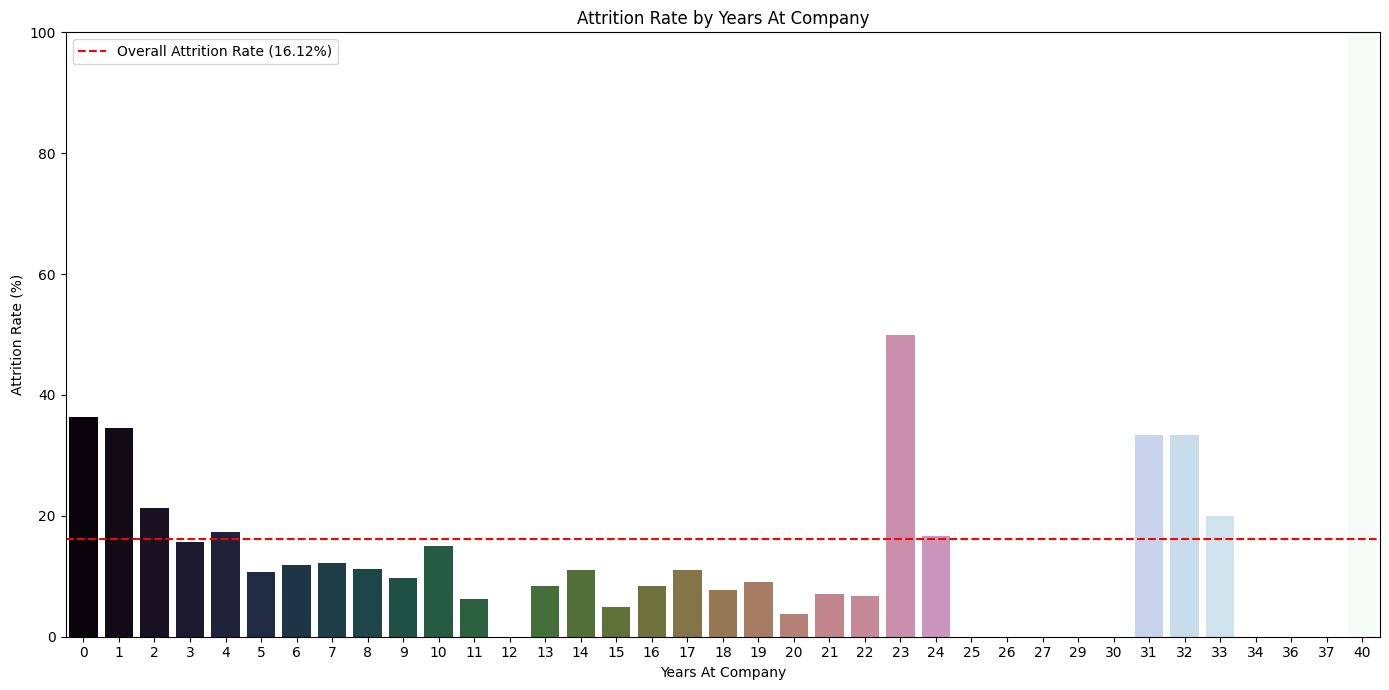

In [28]:
YearsAtCompany_attrition = df.groupby(['YearsAtCompany', 'Attrition']).size().unstack(fill_value=0)
YearsAtCompany_attrition['AttritionRate'] = (YearsAtCompany_attrition['Yes'] / (YearsAtCompany_attrition['No'] + YearsAtCompany_attrition['Yes'])) * 100
print(YearsAtCompany_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(14, 7))
sns.barplot(x=YearsAtCompany_attrition.index, y=YearsAtCompany_attrition['AttritionRate'], palette='cubehelix')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years At Company')
plt.xlabel('Years At Company')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of YearsAtCompany on Attrition Rate

From above plot it is clear that YearsAtCompany above 10 years have very less input data points which may mislead to the attrition rate  Analysis so upto 10 YearsAtCompany should me considered for Analysis instead of all 40 Years Data Points

Attrition       Yes   No  AttritionRate
YearsAtCompany                         
0                16   28      36.363636
1                59  112      34.502924
2                27  100      21.259843
3                20  108      15.625000
4                19   91      17.272727
5                21  175      10.714286
6                 9   67      11.842105
7                11   79      12.222222
8                 9   71      11.250000
9                 8   74       9.756098
10               18  102      15.000000
11                2   30       6.250000
12                0   14       0.000000
13                2   22       8.333333
14                2   16      11.111111
15                1   19       5.000000
16                1   11       8.333333
17                1    8      11.111111
18                1   12       7.692308
19                1   10       9.090909
20                1   26       3.703704
21                1   13       7.142857
22                1   14       6.666667


/tmp/ipykernel_3691/4027423645.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_years_at_company.index, y=filtered_years_at_company['AttritionRate'], palette='cubehelix')


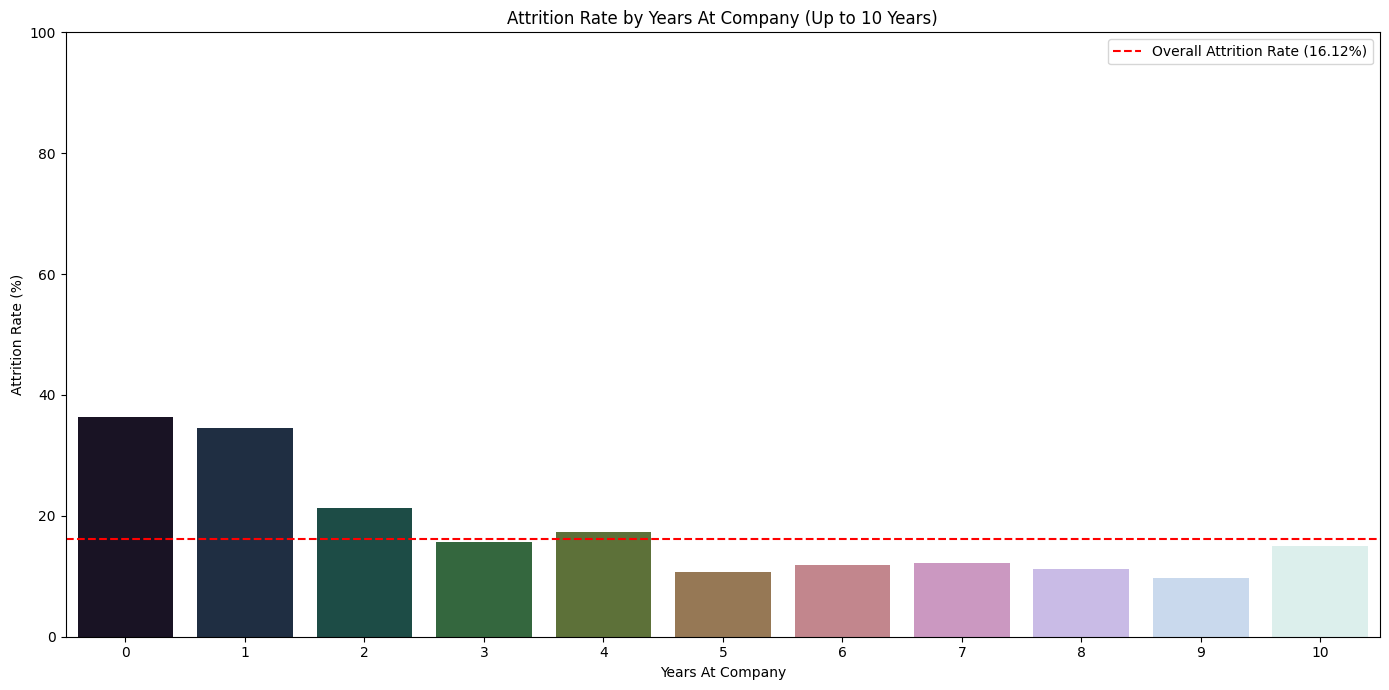

In [29]:
YearsAtCompany_attrition = df.groupby(['YearsAtCompany', 'Attrition']).size().unstack(fill_value=0)
YearsAtCompany_attrition['AttritionRate'] = (YearsAtCompany_attrition['Yes'] / (YearsAtCompany_attrition['No'] + YearsAtCompany_attrition['Yes'])) * 100
print(YearsAtCompany_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for YearsAtCompany up to 10
filtered_years_at_company = YearsAtCompany_attrition[YearsAtCompany_attrition.index <= 10]

plt.figure(figsize=(14, 7))
sns.barplot(x=filtered_years_at_company.index, y=filtered_years_at_company['AttritionRate'], palette='cubehelix')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years At Company (Up to 10 Years)')
plt.xlabel('Years At Company')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition           Yes   No  AttritionRate
YearsInCurrentRole                         
0                    73  171      29.918033
1                    11   46      19.298246
2                    68  304      18.279570
3                    16  119      11.851852
4                    15   89      14.423077
5                     1   35       2.777778
6                     2   35       5.405405
7                    31  191      13.963964
8                     7   82       7.865169
9                     6   61       8.955224
10                    2   27       6.896552
11                    0   22       0.000000
12                    1    9      10.000000
13                    1   13       7.142857
14                    1   10       9.090909
15                    2    6      25.000000
16                    0    7       0.000000
17                    0    4       0.000000
18                    0    2       0.000000


/tmp/ipykernel_3691/3980802950.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=YearsInCurrentRole_attrition.index, y=YearsInCurrentRole_attrition['AttritionRate'], palette='viridis')


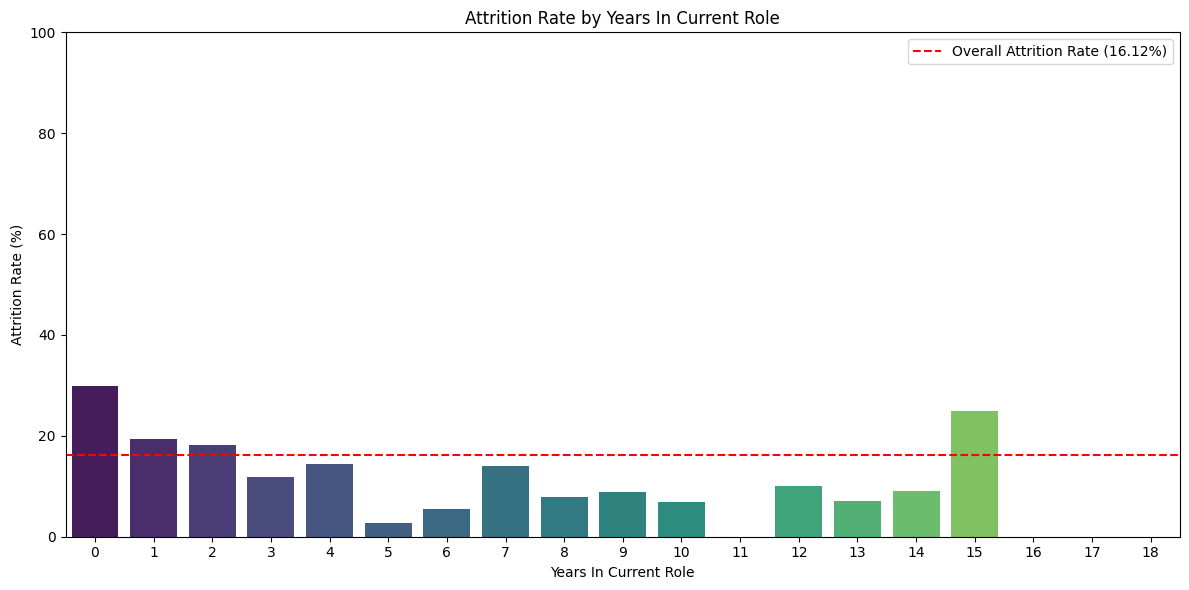

In [32]:
YearsInCurrentRole_attrition = df.groupby(['YearsInCurrentRole', 'Attrition']).size().unstack(fill_value=0)
YearsInCurrentRole_attrition['AttritionRate'] = (YearsInCurrentRole_attrition['Yes'] / (YearsInCurrentRole_attrition['No'] + YearsInCurrentRole_attrition['Yes'])) * 100
print(YearsInCurrentRole_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(12, 6))
sns.barplot(x=YearsInCurrentRole_attrition.index, y=YearsInCurrentRole_attrition['AttritionRate'], palette='viridis')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years In Current Role')
plt.xlabel('Years In Current Role')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of YearsInCurrentRole on Attrition Rate

From above plot it is clear that YearsInCurrentRole above 7 years have very less input data points which may mislead to the attrition rate Analysis so upto 7 YearsInCurrentRole should me considered for Analysis instead of all 18 Years Data Points

Attrition           Yes   No  AttritionRate
YearsInCurrentRole                         
0                    73  171      29.918033
1                    11   46      19.298246
2                    68  304      18.279570
3                    16  119      11.851852
4                    15   89      14.423077
5                     1   35       2.777778
6                     2   35       5.405405
7                    31  191      13.963964
8                     7   82       7.865169
9                     6   61       8.955224
10                    2   27       6.896552
11                    0   22       0.000000
12                    1    9      10.000000
13                    1   13       7.142857
14                    1   10       9.090909
15                    2    6      25.000000
16                    0    7       0.000000
17                    0    4       0.000000
18                    0    2       0.000000


/tmp/ipykernel_3691/708402628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_years_in_role.index, y=filtered_years_in_role['AttritionRate'], palette='viridis')


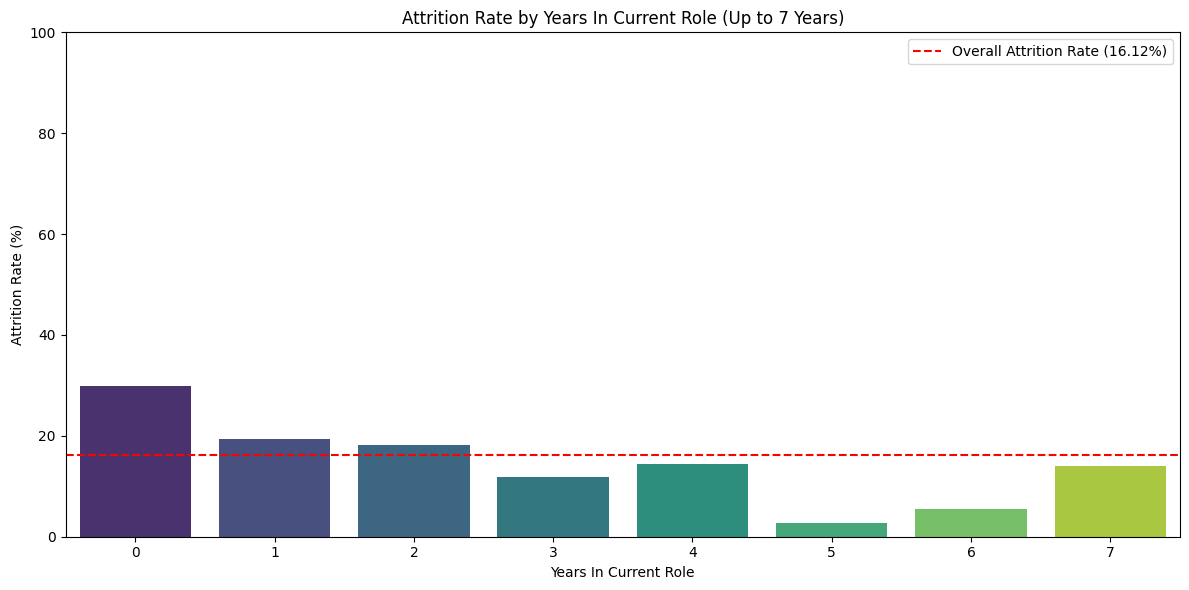

In [31]:
YearsInCurrentRole_attrition = df.groupby(['YearsInCurrentRole', 'Attrition']).size().unstack(fill_value=0)
YearsInCurrentRole_attrition['AttritionRate'] = (YearsInCurrentRole_attrition['Yes'] / (YearsInCurrentRole_attrition['No'] + YearsInCurrentRole_attrition['Yes'])) * 100
print(YearsInCurrentRole_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for YearsInCurrentRole up to 7
filtered_years_in_role = YearsInCurrentRole_attrition[YearsInCurrentRole_attrition.index <= 7]

plt.figure(figsize=(12, 6))
sns.barplot(x=filtered_years_in_role.index, y=filtered_years_in_role['AttritionRate'], palette='viridis')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years In Current Role (Up to 7 Years)')
plt.xlabel('Years In Current Role')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition             Yes   No  AttritionRate
YearsWithCurrManager                         
0                      85  178      32.319392
1                      11   65      14.473684
2                      50  294      14.534884
3                      19  123      13.380282
4                      11   87      11.224490
5                       4   27      12.903226
6                       4   25      13.793103
7                      31  185      14.351852
8                      10   97       9.345794
9                       6   58       9.375000
10                      3   24      11.111111
11                      1   21       4.545455
12                      0   18       0.000000
13                      0   14       0.000000
14                      2    3      40.000000
15                      0    5       0.000000
16                      0    2       0.000000
17                      0    7       0.000000


/tmp/ipykernel_3691/865071933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=YearsWithCurrManager_attrition.index, y=YearsWithCurrManager_attrition['AttritionRate'], palette='cool')


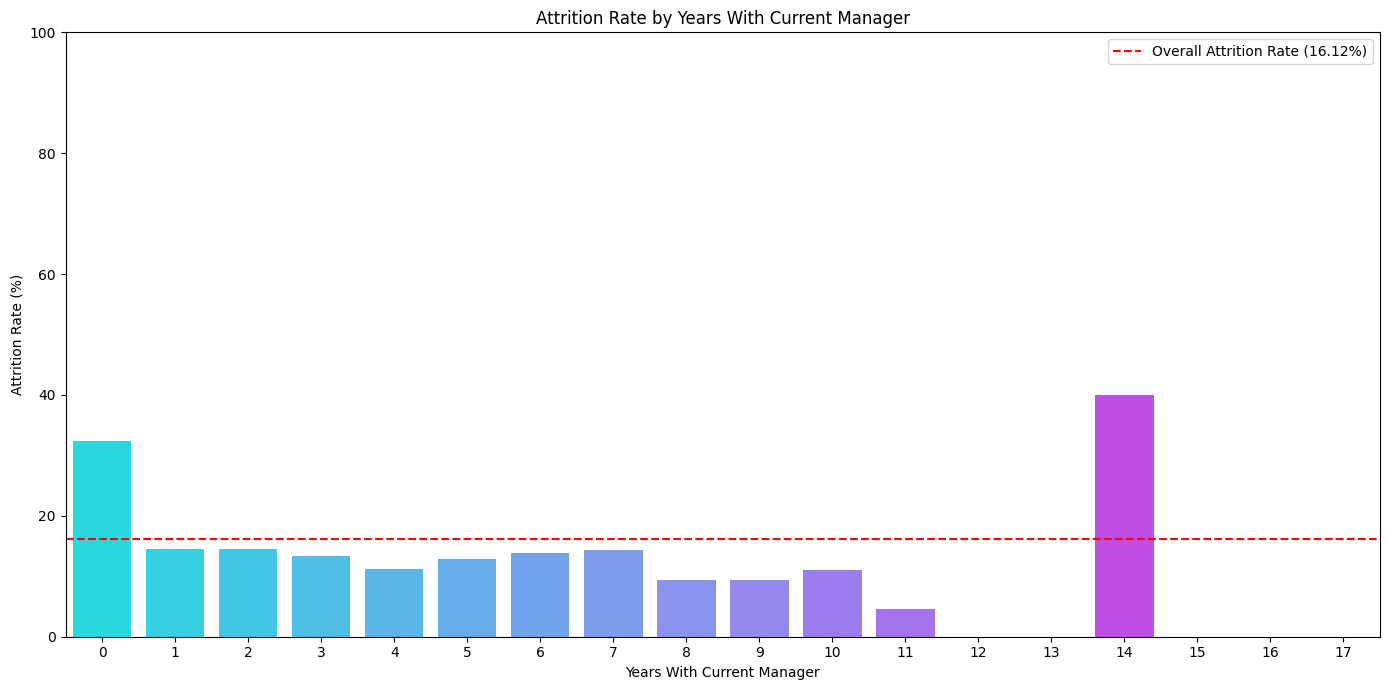

In [34]:
YearsWithCurrManager_attrition = df.groupby(['YearsWithCurrManager', 'Attrition']).size().unstack(fill_value=0)
YearsWithCurrManager_attrition['AttritionRate'] = (YearsWithCurrManager_attrition['Yes'] / (YearsWithCurrManager_attrition['No'] + YearsWithCurrManager_attrition['Yes'])) * 100
print(YearsWithCurrManager_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(14, 7))
sns.barplot(x=YearsWithCurrManager_attrition.index, y=YearsWithCurrManager_attrition['AttritionRate'], palette='cool')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years With Current Manager')
plt.xlabel('Years With Current Manager')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of YearsWithCurrManager on Attrition Rate

From above plot it is clear that YearsWithCurrManager above 8 years have very less input data points which may mislead to the attrition rate Analysis so upto 8 YearsWithCurrManager should me considered for Analysis instead of all 17 Years Data Points

Attrition             Yes   No  AttritionRate
YearsWithCurrManager                         
0                      85  178      32.319392
1                      11   65      14.473684
2                      50  294      14.534884
3                      19  123      13.380282
4                      11   87      11.224490
5                       4   27      12.903226
6                       4   25      13.793103
7                      31  185      14.351852
8                      10   97       9.345794
9                       6   58       9.375000
10                      3   24      11.111111
11                      1   21       4.545455
12                      0   18       0.000000
13                      0   14       0.000000
14                      2    3      40.000000
15                      0    5       0.000000
16                      0    2       0.000000
17                      0    7       0.000000


/tmp/ipykernel_3691/2547461442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_years_with_curr_manager.index, y=filtered_years_with_curr_manager['AttritionRate'], palette='cool')


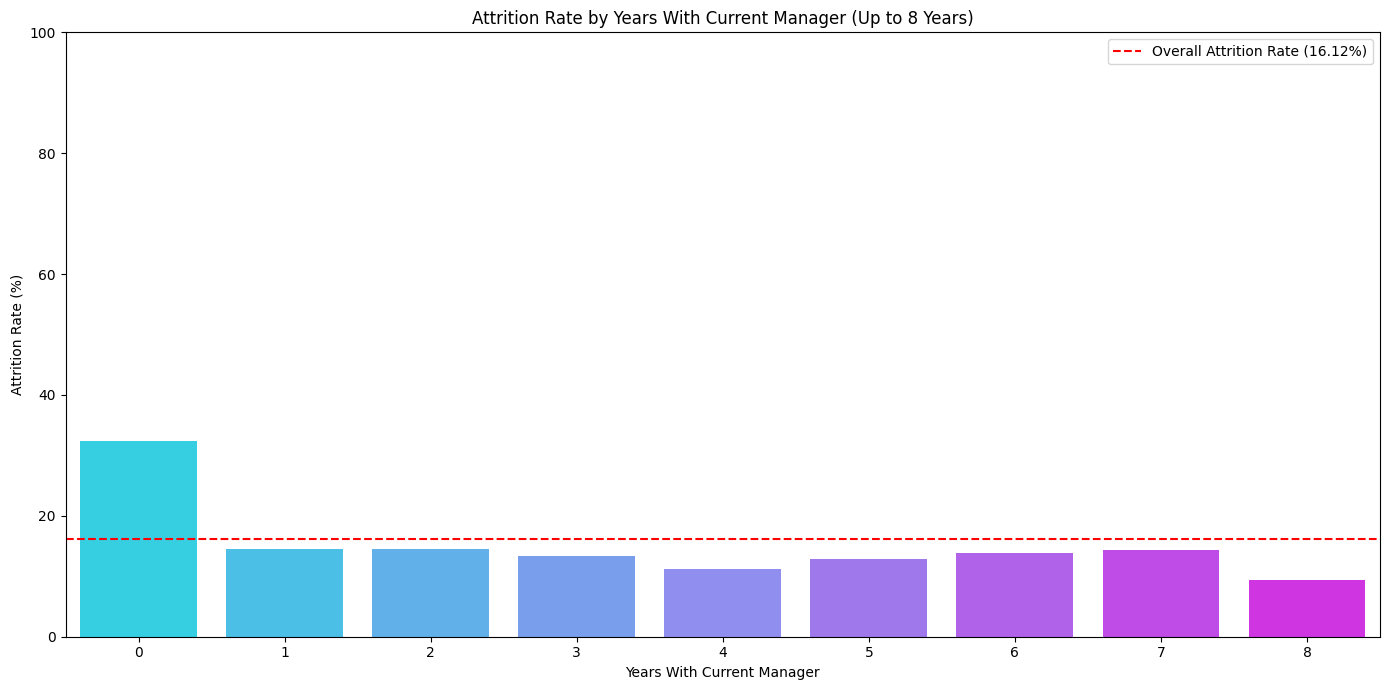

In [35]:
YearsWithCurrManager_attrition = df.groupby(['YearsWithCurrManager', 'Attrition']).size().unstack(fill_value=0)
YearsWithCurrManager_attrition['AttritionRate'] = (YearsWithCurrManager_attrition['Yes'] / (YearsWithCurrManager_attrition['No'] + YearsWithCurrManager_attrition['Yes'])) * 100
print(YearsWithCurrManager_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for YearsWithCurrManager up to 8
filtered_years_with_curr_manager = YearsWithCurrManager_attrition[YearsWithCurrManager_attrition.index <= 8]

plt.figure(figsize=(14, 7))
sns.barplot(x=filtered_years_with_curr_manager.index, y=filtered_years_with_curr_manager['AttritionRate'], palette='cool')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Years With Current Manager (Up to 8 Years)')
plt.xlabel('Years With Current Manager')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of PercentSalaryHike on Attrition Rate

Attrition          Yes   No  AttritionRate
PercentSalaryHike                         
11                  41  169      19.523810
12                  33  165      16.666667
13                  34  175      16.267943
14                  24  177      11.940299
15                  18   83      17.821782
16                  14   64      17.948718
17                  14   68      17.073171
18                  13   76      14.606742
19                   9   67      11.842105
20                   7   48      12.727273
21                   5   43      10.416667
22                  12   44      21.428571
23                   6   22      21.428571
24                   6   15      28.571429
25                   1   17       5.555556


/tmp/ipykernel_3691/2980989547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=PercentSalaryHike_attrition.index, y=PercentSalaryHike_attrition['AttritionRate'], palette='plasma')


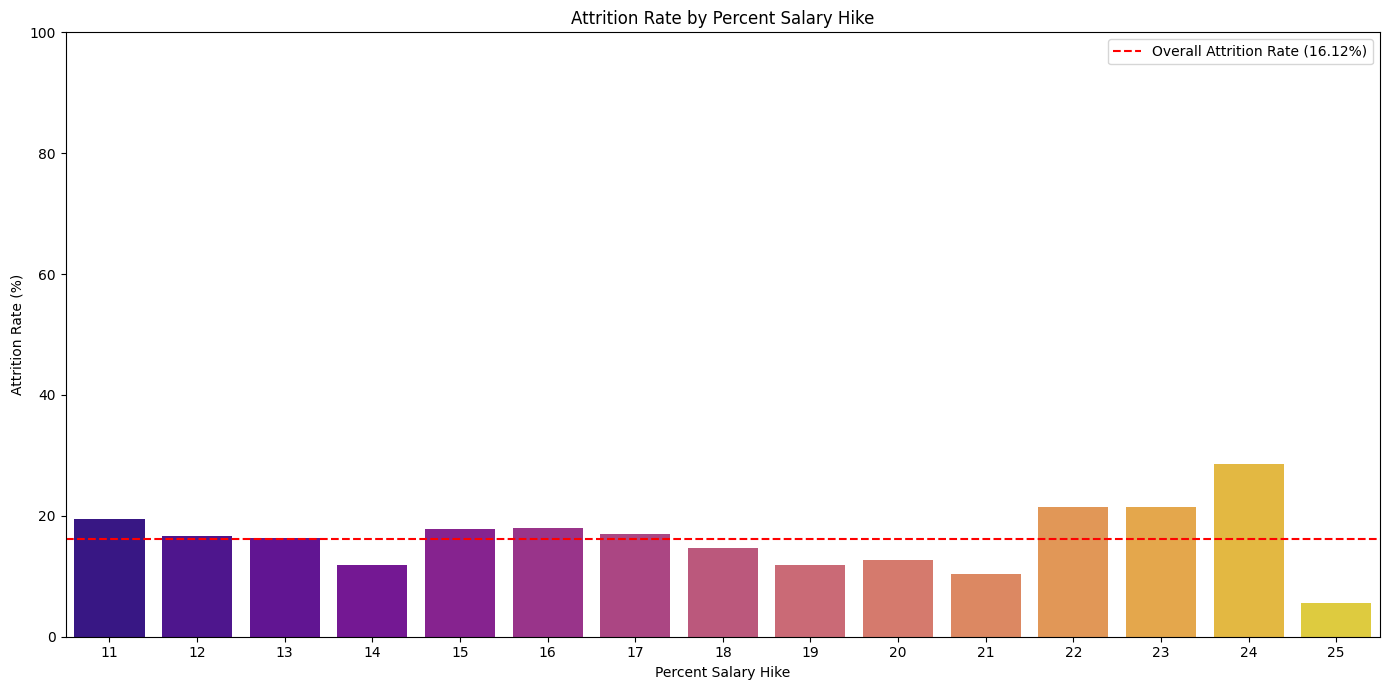

In [38]:
PercentSalaryHike_attrition = df.groupby(['PercentSalaryHike', 'Attrition']).size().unstack(fill_value=0)
PercentSalaryHike_attrition['AttritionRate'] = (PercentSalaryHike_attrition['Yes'] / (PercentSalaryHike_attrition['No'] + PercentSalaryHike_attrition['Yes'])) * 100
print(PercentSalaryHike_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(14, 7))

sns.barplot(x=PercentSalaryHike_attrition.index, y=PercentSalaryHike_attrition['AttritionRate'], palette='plasma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Percent Salary Hike')
plt.xlabel('Percent Salary Hike')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition          Yes   No  AttritionRate
PercentSalaryHike                         
11                  41  169      19.523810
12                  33  165      16.666667
13                  34  175      16.267943
14                  24  177      11.940299
15                  18   83      17.821782
16                  14   64      17.948718
17                  14   68      17.073171
18                  13   76      14.606742
19                   9   67      11.842105
20                   7   48      12.727273
21                   5   43      10.416667
22                  12   44      21.428571
23                   6   22      21.428571
24                   6   15      28.571429
25                   1   17       5.555556


/tmp/ipykernel_3691/1362199890.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_percent_salary_hike.index, y=filtered_percent_salary_hike['AttritionRate'], palette='plasma')


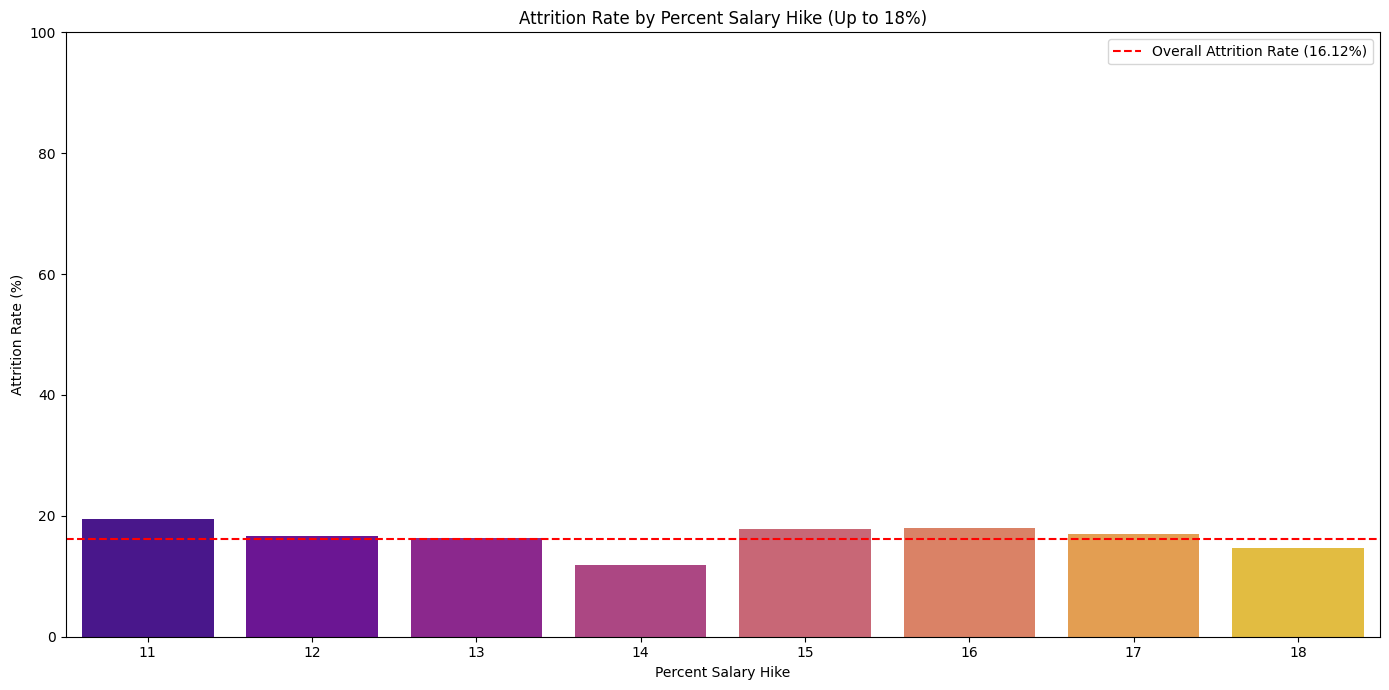

In [37]:
PercentSalaryHike_attrition = df.groupby(['PercentSalaryHike', 'Attrition']).size().unstack(fill_value=0)
PercentSalaryHike_attrition['AttritionRate'] = (PercentSalaryHike_attrition['Yes'] / (PercentSalaryHike_attrition['No'] + PercentSalaryHike_attrition['Yes'])) * 100
print(PercentSalaryHike_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for PercentSalaryHike up to 18
filtered_percent_salary_hike = PercentSalaryHike_attrition[PercentSalaryHike_attrition.index <= 18]

plt.figure(figsize=(14, 7))
sns.barplot(x=filtered_percent_salary_hike.index, y=filtered_percent_salary_hike['AttritionRate'], palette='plasma')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Percent Salary Hike (Up to 18%)')
plt.xlabel('Percent Salary Hike')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of OverTime on Attrition Rate

Attrition  Yes   No  AttritionRate
OverTime                          
No         110  944      10.436433
Yes        127  289      30.528846


/tmp/ipykernel_3691/3187152107.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=OverTime_attrition.index, y=OverTime_attrition['AttritionRate'], palette='viridis')


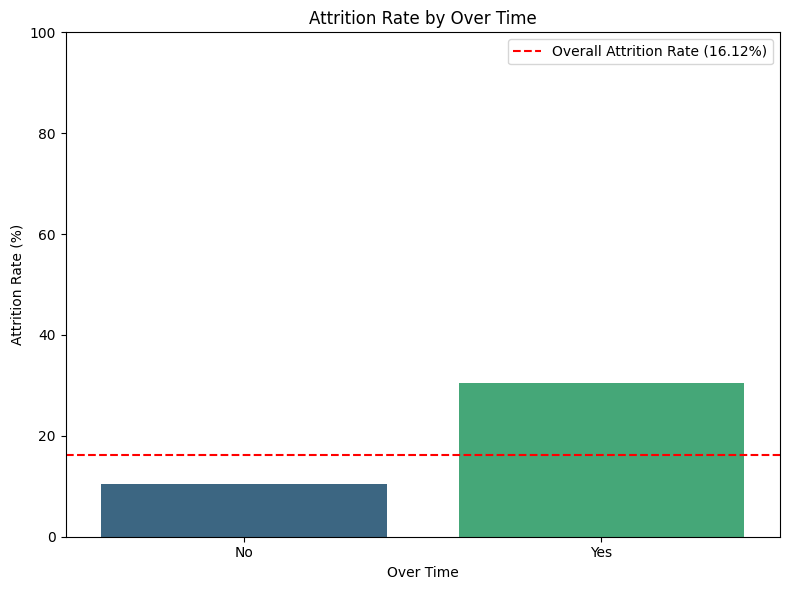

In [39]:
OverTime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
OverTime_attrition['AttritionRate'] = (OverTime_attrition['Yes'] / (OverTime_attrition['No'] + OverTime_attrition['Yes'])) * 100
print(OverTime_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(8, 6))
sns.barplot(x=OverTime_attrition.index, y=OverTime_attrition['AttritionRate'], palette='viridis')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Over Time')
plt.xlabel('Over Time')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of MaritalStatus on Attrition Rate

Attrition      Yes   No  AttritionRate
MaritalStatus                         
Divorced        33  294      10.091743
Married         84  589      12.481426
Single         120  350      25.531915


/tmp/ipykernel_3691/2285810130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=MaritalStatus_attrition.index, y=MaritalStatus_attrition['AttritionRate'], palette='cubehelix')


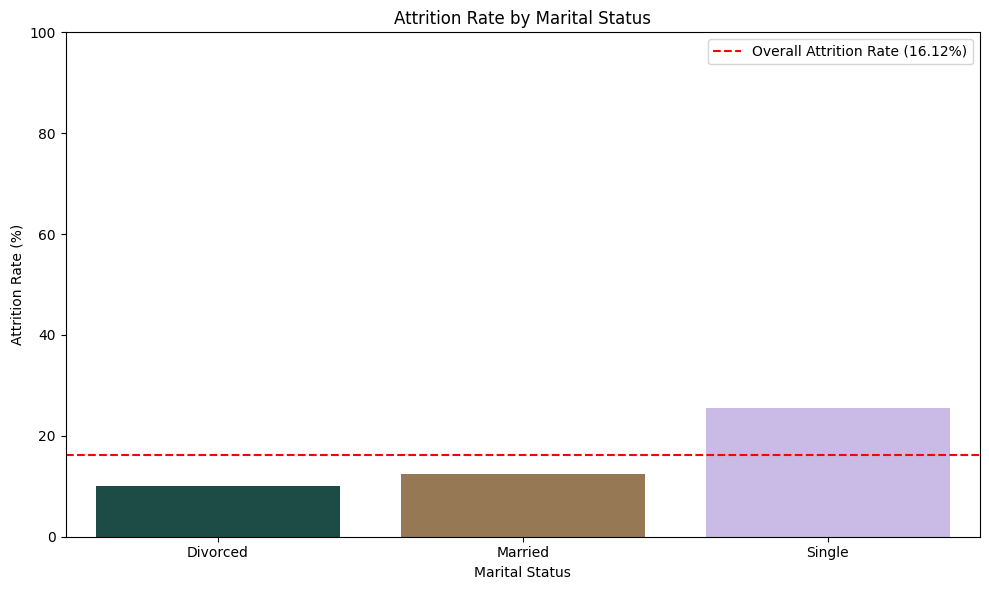

In [40]:
MaritalStatus_attrition = df.groupby(['MaritalStatus', 'Attrition']).size().unstack(fill_value=0)
MaritalStatus_attrition['AttritionRate'] = (MaritalStatus_attrition['Yes'] / (MaritalStatus_attrition['No'] + MaritalStatus_attrition['Yes'])) * 100
print(MaritalStatus_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=MaritalStatus_attrition.index, y=MaritalStatus_attrition['AttritionRate'], palette='cubehelix')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of DistanceFromHome on Attrition Rate

Attrition         Yes   No  AttritionRate
DistanceFromHome                         
1                  26  182      12.500000
2                  28  183      13.270142
3                  14   70      16.666667
4                   9   55      14.062500
5                  10   55      15.384615
6                   7   52      11.864407
7                  11   73      13.095238
8                  10   70      12.500000
9                  18   67      21.176471
10                 11   75      12.790698
11                  4   25      13.793103
12                  6   14      30.000000
13                  6   13      31.578947
14                  4   17      19.047619
15                  5   21      19.230769
16                  7   25      21.875000
17                  5   15      25.000000
18                  4   22      15.384615
19                  3   19      13.636364
20                  4   21      16.000000
21                  3   15      16.666667
22                  6   13      31

/tmp/ipykernel_3691/1238911901.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=DistanceFromHome_attrition.index, y=DistanceFromHome_attrition['AttritionRate'], palette='YlGnBu')


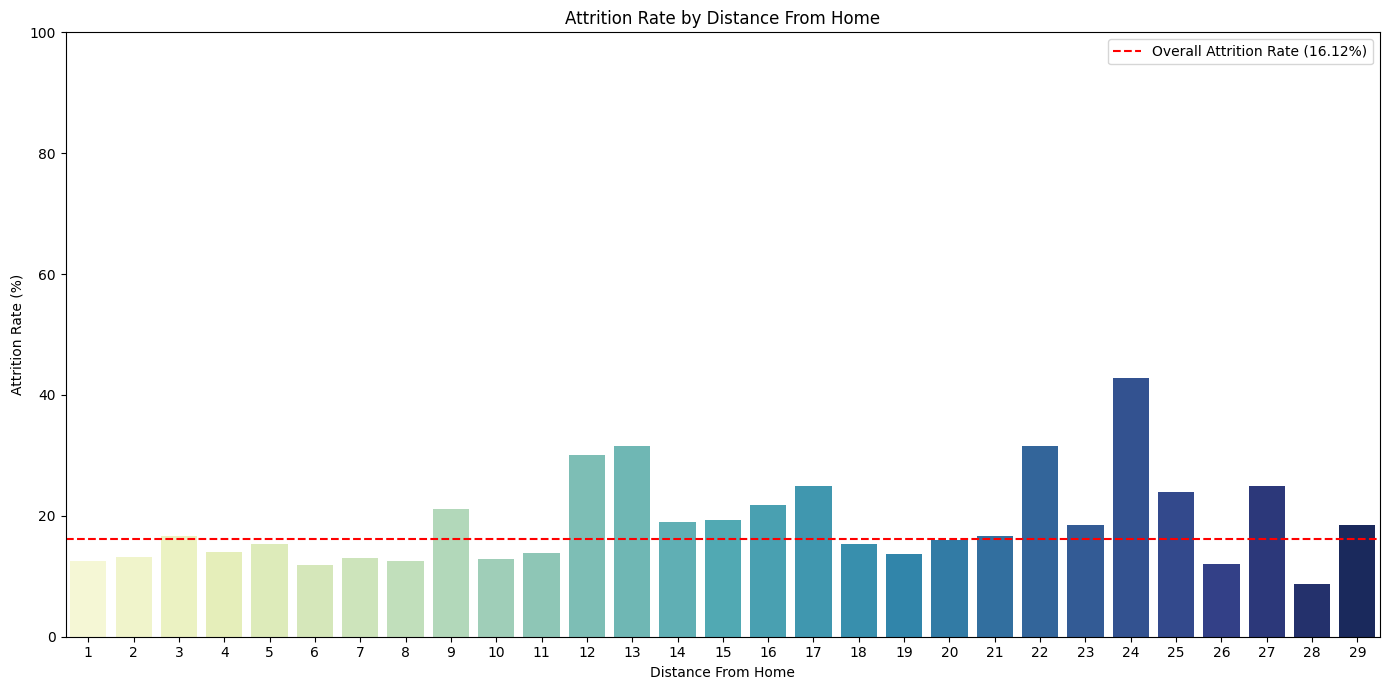

In [42]:
DistanceFromHome_attrition = df.groupby(['DistanceFromHome', 'Attrition']).size().unstack(fill_value=0)
DistanceFromHome_attrition['AttritionRate'] = (DistanceFromHome_attrition['Yes'] / (DistanceFromHome_attrition['No'] + DistanceFromHome_attrition['Yes'])) * 100
print(DistanceFromHome_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(14, 7))
sns.barplot(x=DistanceFromHome_attrition.index, y=DistanceFromHome_attrition['AttritionRate'], palette='YlGnBu')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Distance From Home')
plt.xlabel('Distance From Home')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

Attrition         Yes   No  AttritionRate
DistanceFromHome                         
1                  26  182      12.500000
2                  28  183      13.270142
3                  14   70      16.666667
4                   9   55      14.062500
5                  10   55      15.384615
6                   7   52      11.864407
7                  11   73      13.095238
8                  10   70      12.500000
9                  18   67      21.176471
10                 11   75      12.790698
11                  4   25      13.793103
12                  6   14      30.000000
13                  6   13      31.578947
14                  4   17      19.047619
15                  5   21      19.230769
16                  7   25      21.875000
17                  5   15      25.000000
18                  4   22      15.384615
19                  3   19      13.636364
20                  4   21      16.000000
21                  3   15      16.666667
22                  6   13      31

/tmp/ipykernel_3691/1066512512.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_distance_from_home.index, y=filtered_distance_from_home['AttritionRate'], palette='YlGnBu')


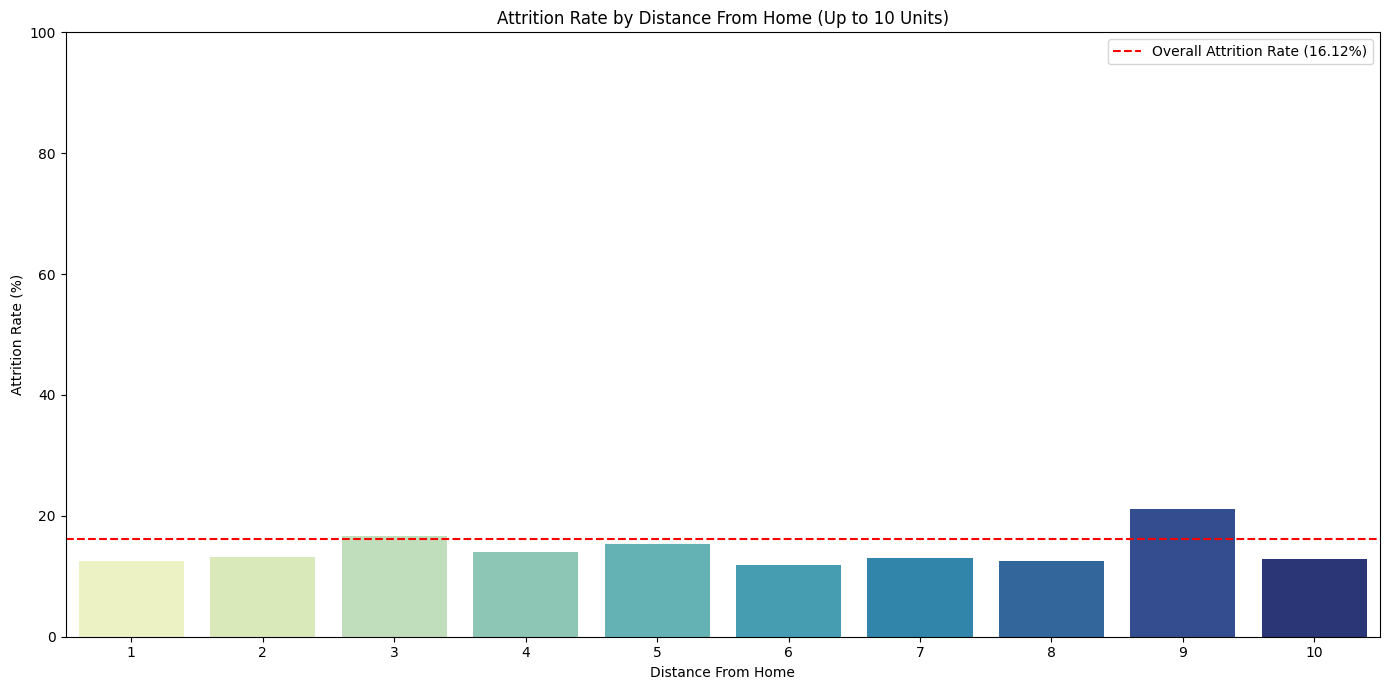

In [43]:
DistanceFromHome_attrition = df.groupby(['DistanceFromHome', 'Attrition']).size().unstack(fill_value=0)
DistanceFromHome_attrition['AttritionRate'] = (DistanceFromHome_attrition['Yes'] / (DistanceFromHome_attrition['No'] + DistanceFromHome_attrition['Yes'])) * 100
print(DistanceFromHome_attrition[['Yes', 'No', 'AttritionRate']])

# Filter for DistanceFromHome up to 10
filtered_distance_from_home = DistanceFromHome_attrition[DistanceFromHome_attrition.index <= 10]

plt.figure(figsize=(14, 7))
sns.barplot(x=filtered_distance_from_home.index, y=filtered_distance_from_home['AttritionRate'], palette='YlGnBu')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Distance From Home (Up to 10 Units)')
plt.xlabel('Distance From Home')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Impact of JobInvolvement on Attrition Rate

Attrition       Yes   No  AttritionRate
JobInvolvement                         
1                28   55      33.734940
2                71  304      18.933333
3               125  743      14.400922
4                13  131       9.027778


/tmp/ipykernel_3691/596350738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=JobInvolvement_attrition.index, y=JobInvolvement_attrition['AttritionRate'], palette='viridis')


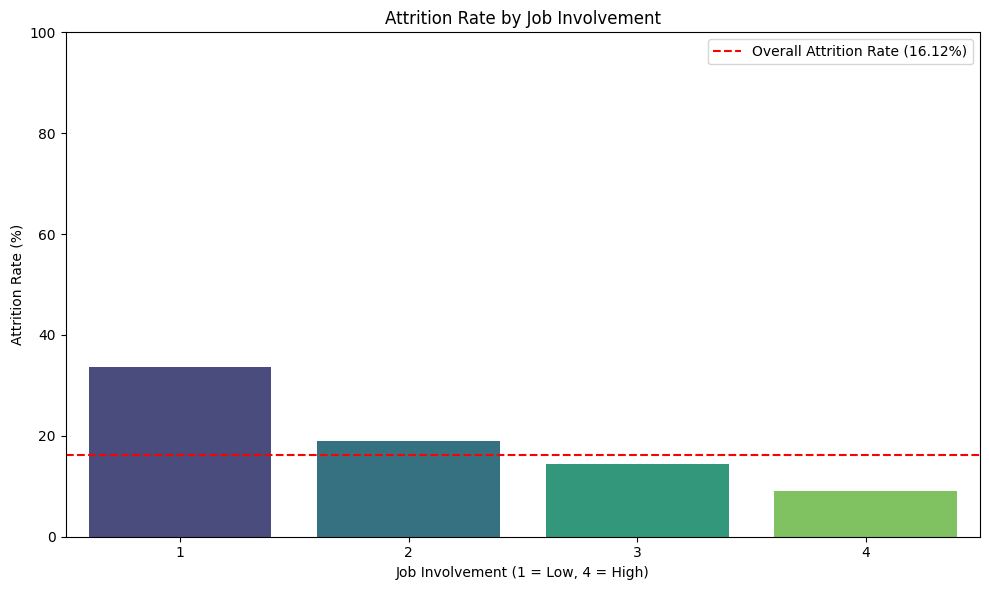

In [44]:
JobInvolvement_attrition = df.groupby(['JobInvolvement', 'Attrition']).size().unstack(fill_value=0)
JobInvolvement_attrition['AttritionRate'] = (JobInvolvement_attrition['Yes'] / (JobInvolvement_attrition['No'] + JobInvolvement_attrition['Yes'])) * 100
print(JobInvolvement_attrition[['Yes', 'No', 'AttritionRate']])

plt.figure(figsize=(10, 6))
sns.barplot(x=JobInvolvement_attrition.index, y=JobInvolvement_attrition['AttritionRate'], palette='viridis')
plt.axhline(y=attrition_rate['Yes'], color='red', linestyle='--', label=f'Overall Attrition Rate ({attrition_rate['Yes']:.2f}%)')
plt.title('Attrition Rate by Job Involvement')
plt.xlabel('Job Involvement (1 = Low, 4 = High)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## Final Attrition Analysis Summary Report

**Overall Attrition Rate:** The dataset shows an overall attrition rate of **16.12%**.

### Key Factors Impacting Attrition:

1.  **Job Satisfaction:**
    *   Employees with **Low Job Satisfaction (Level 1)** exhibit a significantly higher attrition rate (**22.84%**), well above the overall average.
    *   Conversely, those with **High Job Satisfaction (Level 4)** have a lower attrition rate (**11.33%**).

2.  **Work-Life Balance:**
    *   A **Poor Work-Life Balance (Level 1)** is strongly associated with high attrition (**31.25%**).
    *   Employees reporting a **Good Work-Life Balance (Level 3)** show a lower attrition rate (**14.22%**).

3.  **Years Since Last Promotion:**
    *   Attrition is relatively higher for employees with **0 years** since their last promotion (**18.93%**), suggesting that new promotions might sometimes be followed by attrition if expectations are not met or new opportunities arise.
    *   There's also a notable increase at **7 years** (**21.05%**).
    *   Attrition is considerably lower at **5 years** (**4.44%**), possibly indicating a period of stability.

4.  **Years At Company:**
    *   **New employees (0-1 years at company)** show a substantially higher attrition rate (**36.36% for 0 years, 34.50% for 1 year**).
    *   The attrition rate generally **decreases as the number of years at the company increases**, suggesting higher loyalty and satisfaction among long-tenured employees.

5.  **Years In Current Role:**
    *   Similar to Years At Company, employees with **0 years in their current role** have a much higher attrition rate (**29.92%**).
    *   The attrition rate tends to **decrease with more years in the current role**, indicating that stability in a role reduces the likelihood of attrition. However, there is a small increase around 7 years.

6.  **Years With Current Manager:**
    *   Employees with **0 years with their current manager** show a significantly high attrition rate (**32.32%**).
    *   Attrition generally **decreases as employees spend more years with the same manager**, implying that a stable relationship with a manager contributes to retention.

7.  **Percent Salary Hike:**
    *   Lower percentage salary hikes (e.g., **11% at 19.52%**) appear to correlate with higher attrition rates compared to the overall average.
    *   Conversely, higher salary hikes (e.g., **14% at 11.94%**) tend to have lower attrition rates.

8.  **Over Time:**
    *   Employees who work **Over Time** have a significantly higher attrition rate (**30.53%**) compared to those who do not (**10.44%**).

9.  **Marital Status:**
    *   **Single employees** have a substantially higher attrition rate (**25.53%**) than Married (**12.48%**) or Divorced (**10.09%**) employees.

10. **Distance From Home:**
    *   Attrition rates fluctuate with distance. While there isn't a clear linear trend, some distances, such as **9 units (21.18%)**, show higher attrition than the overall average.

11. **Job Involvement:**
    *   **Low Job Involvement (Level 1)** is a strong predictor of attrition, with a rate of **33.73%**.
    *   Employees with **High Job Involvement (Level 4)** have a considerably lower attrition rate (**9.03%**).

### General Observations:
*   **High attrition rates are consistently observed among employees in the early stages** of their tenure at the company, in their current role, or with their current manager. This highlights the importance of effective onboarding, early career development, and strong initial managerial relationships.
*   **Employee well-being factors** such as Job Satisfaction and Work-Life Balance play a critical role, with lower satisfaction and poorer balance leading to higher attrition.
*   **Compensation (Percent Salary Hike)** and **workload (Over Time)** are also significant factors, indicating that fair compensation and manageable work hours are crucial for retention.
*   **Marital Status** suggests that single individuals might be more mobile or open to new opportunities.

This summary provides a foundational understanding of the factors influencing attrition within the company, indicating several areas where interventions could be targeted to improve employee retention.